# Q8.
```{admonition}
:class: note
In this problem, we will simulate data from $m = 100$ fund managers.
    
These data represent each fund manager's percentage returns for each of $n = 20$ months. We wish to test the null hypothesis that each fund manager's percentage returns have population mean equal to zero. Notice that we simulated the data in such a way that each fund manager's percentage returns do have population mean zero; in other words, all $m$ null hypotheses are true.

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_1samp
import matplotlib.pyplot as plt

In [3]:
import statsmodels.api as sm

In [4]:
import seaborn as sns

In [5]:
rng = np.random.default_rng(1)
n, m = 20, 100
X = rng.normal(size=(n,m))

## (a)
```{admonition}
:class: note
Conduct a one-sample $t$-test for each fund manager, and plot a histogram of the $p$-values obtained.

In [6]:
pvals = {}
for i in range(m):
    pvals[i] = ttest_1samp(X[:,i],popmean=0.0).pvalue
pval_df = pd.DataFrame.from_dict(pvals,orient='index',columns=['p'])

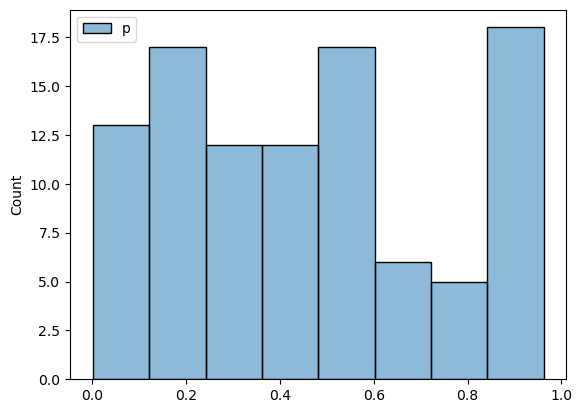

In [7]:
sns.histplot(pval_df)
plt.show()

## (b)
```{admonition}
:class: note
If we control Type I error for each null hypothesis at level $\alpha = 0.05$, then how many null hypotheses do we reject?

In [8]:
print((pval_df < 0.05).sum().iloc[0])

4


## (c)
```{admonition}
:class: note
If we control the FWER at level $0.05$, then how many null hypotheses do we reject?

In [9]:
print('FWER control using Bonferonni:', sm.stats.multipletests(pval_df['p'],alpha=0.05,method='bonferroni')[0].sum())

FWER control using Bonferonni: 0


In [10]:
print('FWER control using Holm:', sm.stats.multipletests(pval_df['p'],alpha=0.05,method='bonferroni')[0].sum())

FWER control using Holm: 0


## (d)
```{admonition}
:class: note
If we control the FDR at level $0.05$, then how many null hypotheses do we reject?

In [11]:
print('FDR control using Benjamini-Hochberg:', sm.stats.multipletests(pval_df['p'],alpha=0.05,method='fdr_bh')[0].sum())

FDR control using Benjamini-Hochberg: 0


## (e)
```{admonition}
:class: note
Now suppose we "cherry-pick" the $10$ fund managers who perform the best in our data. If we control the FWER for just these $10$ fund managers at level $0.05$, then how many null hypotheses do we reject? If we control the FDR for just these $10$ fund
managers at level $0.05$, then how many null hypotheses do we reject?

In [12]:
top_ten = pval_df.sort_values(by='p').index[:10]
pval_df_cherry = pval_df.iloc[top_ten]

In [13]:
print('FWER control using Bonferonni:', sm.stats.multipletests(pval_df_cherry['p'],alpha=0.05,method='bonferroni')[0].sum())

FWER control using Bonferonni: 1


In [14]:
print('FWER control using Holm:', sm.stats.multipletests(pval_df_cherry['p'],alpha=0.05,method='holm')[0].sum())

FWER control using Holm: 1


In [15]:
print('FDR control using Benjamini-Hochberg:', sm.stats.multipletests(pval_df_cherry['p'],alpha=0.05,method='fdr_bh')[0].sum())

FDR control using Benjamini-Hochberg: 2


## (f)
```{admonition}
:class: note
Explain why the analysis in (e) is misleading.

When controlling for the number of hypothesis, we assume that the hypothesis to be tested were set before testing. By choosing the best $10$ $p$-values, we are conditioning on rarer events after testing. In the most extreme case, choosing the best $p$-value and then controlling for the number of hypothesis would require no multiple testing adjustment.
